[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LeinMS/hse-image-captioning/blob/main/src/run_inference/Qwen3_VL_2B_Instruct_trl_sft_run_inference.ipynb)


In [2]:
import sys

!{sys.executable} -m pip install transformers -q
!{sys.executable} -m pip install accelerate -q
!{sys.executable} -m pip install flash-attn --no-build-isolation -q
!{sys.executable} -m pip install datasets -q

In [3]:
!nvidia-smi

Sun Dec 21 13:57:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Loading of the model

In [4]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
from peft import PeftModel

base_model_name = "Qwen/Qwen3-VL-2B-Instruct"     # original model
adapter_name = "leinms/Qwen3-VL-2B-Instruct-trl-sft"  # LoRA

# Load base model
model = Qwen3VLForConditionalGeneration.from_pretrained(
    base_model_name,
    dtype="auto",
    device_map="cuda",
)

# Load LoRA weights
model = PeftModel.from_pretrained(model, adapter_name)

processor = AutoProcessor.from_pretrained(base_model_name)
torch.cuda.is_available(), torch.cuda.get_device_name(0)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


(True, 'Tesla T4')

#Loading a dataset that was not used for additional training Qwen3-VL-2b

In [7]:
from datasets import load_dataset

ds_small = load_dataset("bodhisattamaiti/StylExNet5k", split="train[:10%]")

#Function for the model inference

In [11]:
def caption_with_qwen(example):
    test_example_image = example["image"]


    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": test_example_image,
                },
                {"type": "text", "text": "Describe this image."},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            # temperature=0.0,
        )

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0]

    return {"baseline_answ": output_text.strip()}


#Check fime-tuned model

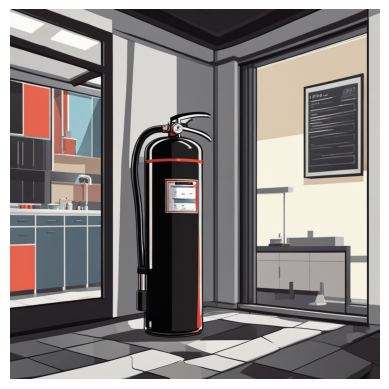

(1686, 'A fire extinguisher in a modern kitchen.')

In [24]:
import random
import matplotlib.pyplot as plt

def show_and_caption_random(ds):
    """
    Selects a random image from the ds dataset,
    displays it and calls caption_with_qwen.
    """
    idx = random.randint(0, len(ds) - 1)


    example = ds[idx]
    img = example["image"]  # PIL.Image

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    result = caption_with_qwen(example)

    return idx, result['baseline_answ']

show_and_caption_random(ds_small)